In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from monai.networks.nets import UNet
from monai.losses import DiceLoss
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [21]:
import sys
from pathlib import Path

ROOT = Path("/homes/cmininno/cvcs2026/Surgical-Copilot")
SRC = ROOT / "src"

sys.path.insert(0, str(SRC))

print("Project root:", ROOT)
print("Src path:", SRC)

from surgical_copilot.bench.BenchmarkEngine import BenchmarkEngine
from surgical_copilot.HemoDataset import HemosetDataSet
from surgical_copilot.bench.perturbation import PerturbationPipelines

Project root: /homes/cmininno/cvcs2026/Surgical-Copilot
Src path: /homes/cmininno/cvcs2026/Surgical-Copilot/src


In [22]:
cfg = {
    "data": {
        "root_dir": "/homes/cmininno/cvcs2026/Surgical-Copilot/data/raw",
        "img_size": (256, 256),
        "n_folds": 5
    },
    "seed": 42,
    "trainer": {
        "trainer": {
            "batch_size": 8,
            "num_workers": 4
        }
    }
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = HemosetDataSet(
    root_dir=cfg["data"]["root_dir"],
    seed=cfg["seed"],
    image_size=cfg["data"]["img_size"]
)

def get_fold_loaders(fold_idx: int):
    train_loader, val_loader, test_loader = dataset.get_loaders(
        fold_idx=fold_idx,
        n_splits=cfg["data"]["n_folds"],
        batch_size=cfg["trainer"]["trainer"]["batch_size"],
        num_workers=cfg["trainer"]["trainer"]["num_workers"],
        train_transforms=PerturbationPipelines.get_train_pipeline()
    )
    return train_loader, val_loader, test_loader

[*] Dataset caricato: trovati 10 subjects (pigN) distinti.
[*] Totale frame validi: 962


In [23]:
train_loader, val_loader, test_loader = get_fold_loaders(fold_idx=0)


[*] Fold info
Train pigs: ['pig11', 'pig4', 'pig2', 'pig1', 'pig3', 'pig6']
Val pigs:   ['pig9', 'pig10']
Test pigs:  ['pig7', 'pig5']
[*] Samples train=444 val=323 test=195


Loading dataset: 100%|██████████| 195/195 [00:07<00:00, 26.09it/s]


In [24]:
batch = next(iter(train_loader))
print(batch["image"].shape, batch["label"].shape)

torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256])


In [25]:
model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

In [26]:
loss_fn = DiceLoss(sigmoid=True)
optimizer = Adam(model.parameters(), lr=1e-4)

In [27]:
def validate(model, loader):
    model.eval()
    dices = []

    with torch.no_grad():
        for i, batch in enumerate(loader):
            x = batch["image"].to(device)
            y = batch["label"].to(device)

            logits = model(x)
            preds = torch.sigmoid(logits)

            preds = (preds > 0.5).float()

            dice = 1 - torch.mean(torch.abs(preds - y)).item()
            dices.append(dice)

            if i > 20:
                break

    return np.mean(dices)

In [28]:
def train_one_epoch(model, loader):
    model.train()
    losses = []

    for i, batch in enumerate(loader):
        x = batch["image"].to(device)
        y = batch["label"].to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if i > 50:  # QUICK MODE
            break

    return np.mean(losses)

In [41]:
epochs = 50

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    val_dice = validate(model, val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val dice: {val_dice:.4f}")

Epoch 1
Train loss: 0.7624
Val dice: 0.8932
Epoch 2
Train loss: 0.7630
Val dice: 0.9019
Epoch 3
Train loss: 0.7572
Val dice: 0.8985
Epoch 4
Train loss: 0.7581
Val dice: 0.9071
Epoch 5
Train loss: 0.7555
Val dice: 0.9113
Epoch 6
Train loss: 0.7539
Val dice: 0.9150
Epoch 7
Train loss: 0.7549
Val dice: 0.9163
Epoch 8
Train loss: 0.7502
Val dice: 0.9109
Epoch 9
Train loss: 0.7478
Val dice: 0.9197
Epoch 10
Train loss: 0.7489
Val dice: 0.9211
Epoch 11
Train loss: 0.7465
Val dice: 0.9267
Epoch 12
Train loss: 0.7442
Val dice: 0.9293
Epoch 13
Train loss: 0.7439
Val dice: 0.9228
Epoch 14
Train loss: 0.7404
Val dice: 0.9270
Epoch 15
Train loss: 0.7395
Val dice: 0.9300
Epoch 16
Train loss: 0.7357
Val dice: 0.9315
Epoch 17
Train loss: 0.7342
Val dice: 0.9309
Epoch 18
Train loss: 0.7373
Val dice: 0.9357
Epoch 19
Train loss: 0.7307
Val dice: 0.9306
Epoch 20
Train loss: 0.7286
Val dice: 0.9330
Epoch 21
Train loss: 0.7276
Val dice: 0.9328
Epoch 22
Train loss: 0.7243
Val dice: 0.9341
Epoch 23
Train loss

In [39]:
def show_predictions(model, loader, n=4):
    model.eval()

    batch = next(iter(loader))
    x = batch["image"].to(device)
    y = batch["label"].to(device)

    with torch.no_grad():
        preds = torch.sigmoid(model(x))
        preds = (preds > 0.5).cpu().numpy()

    x = x.cpu().numpy()
    y = y.cpu().numpy()

    plt.figure(figsize=(12, 6))

    for i in range(n):
        img = np.transpose(x[i], (1, 2, 0))
        gt = y[i][0]
        pr = preds[i][0]

        plt.subplot(n, 3, i*3 + 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, i*3 + 2)
        plt.imshow(gt, cmap="gray")
        plt.title("GT")
        plt.axis("off")

        plt.subplot(n, 3, i*3 + 3)
        plt.imshow(pr, cmap="gray")
        plt.title("Pred")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

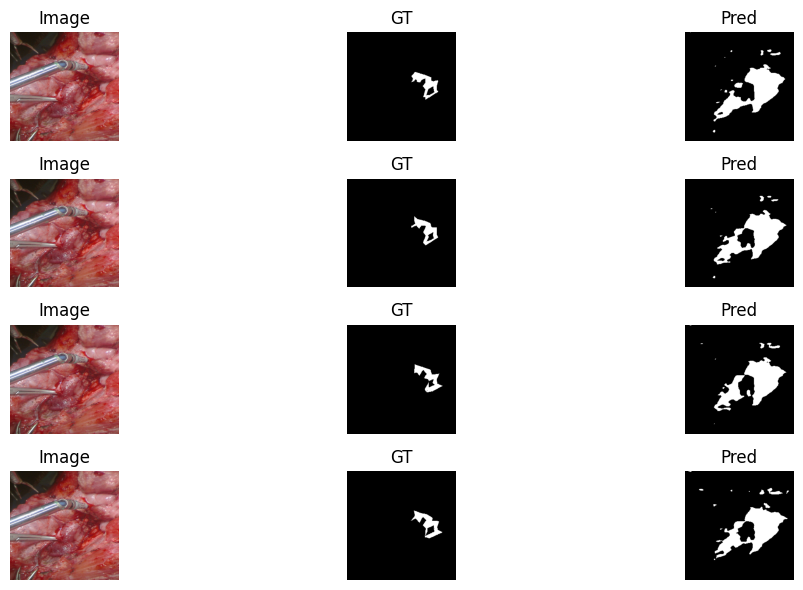

In [42]:
show_predictions(model, val_loader)

In [35]:
def quick_stress(model, loader, pipeline=None):
    model.eval()

    dice_scores = []

    with torch.no_grad():
        for i, batch in enumerate(loader):

            if pipeline:
                batch = pipeline(batch)

            x = batch["image"].to(device)
            y = batch["label"].to(device)

            preds = torch.sigmoid(model(x))
            preds = (preds > 0.5).float()

            dice = 1 - torch.mean(torch.abs(preds - y)).item()
            dice_scores.append(dice)

            if i > 20:
                break

    return np.mean(dice_scores)

In [37]:
quick_stress(model, val_loader)

0.6650528474287554